## Tier 4 — LLM Few-Shot Classification (`qwen3:8b` via Ollama)

Zero training involved, so this isn't evaluated the same way as the TF-IDF/embedding
tiers: no train/test *fitting* happens, no 5-fold CV cell at the end (there's nothing
to re-fit per fold). What still matters for a fair comparison is using the **same
test split** as the other two notebooks, so all three macro-F1 numbers are computed
on the same rows.

Prerequisites (run once, outside this notebook):
```
pip install ollama
ollama pull qwen3:8b
```
...and the Ollama app/server needs to be running locally.


In [11]:
import os
import re
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ollama

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)

In [12]:
df = pd.read_csv('../deshimula_all_reviews_new.csv')
NUM_SAMPLES = 2552
sentiment_df = df[['content', 'vibe']][:NUM_SAMPLES]
sentiment_df.shape

(2552, 2)

In [13]:
X = sentiment_df['content']
y = sentiment_df['vibe']

# Same split as the TF-IDF and embedding notebooks (random_state=42, same stratify)
# so macro-F1 is directly comparable across all tiers.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
print(y_test.value_counts())

Training samples: 2041, Testing samples: 511
vibe
Negative    396
Positive     58
Mixed        57
Name: count, dtype: int64


In [14]:
MODEL = "qwen3:8b"
LABELS = sorted(y.unique().tolist())

# A handful of real few-shot examples pulled from the TRAINING set only
# (never from X_test) -- truncated so the prompt stays short on CPU inference.
FEWSHOT_PER_CLASS = 2
MAX_CHARS = 400

fewshot_df = (
    pd.DataFrame({'content': X_train, 'vibe': y_train})
    .groupby('vibe', group_keys=False)
    .sample(n=FEWSHOT_PER_CLASS, random_state=42)
)
fewshot_examples = [
    (row.content[:MAX_CHARS], row.vibe) for row in fewshot_df.itertuples()
]
len(fewshot_examples)

6

In [ ]:
SYSTEM_PROMPT = (
    "/no_think\n"  # disable Qwen3's chain-of-thought (the `think=False` kwarg
                   # only exists in ollama>=0.5; this tag works on every version)
    "You classify the overall sentiment of employee reviews of Bangladeshi software "
    "companies. Reviews may be written in Bangla, English, Banglish (romanized Bangla), "
    "or a mix of all three within the same review.\n\n"
    f"Classify each review as exactly one of: {', '.join(LABELS)}.\n"
    "- Positive: predominantly favorable, even if minor complaints are mentioned.\n"
    "- Negative: predominantly unfavorable, even if minor positives are mentioned.\n"
    "- Mixed: genuinely balanced pros and cons, with no clear lean either way.\n\n"
    'Respond with only the label as JSON, e.g. {"label": "Positive"}.'
)

RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {"label": {"type": "string", "enum": LABELS}},
    "required": ["label"],
}

def build_messages(review_text):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for example_text, example_label in fewshot_examples:
        messages.append({"role": "user", "content": example_text})
        messages.append({"role": "assistant", "content": json.dumps({"label": example_label})})
    messages.append({"role": "user", "content": review_text[:1500]})
    return messages

In [ ]:
import inspect as _inspect

# ollama < 0.5 (this box has 0.4.8) has no `think` kwarg -- passing it made
# EVERY ollama.chat() call raise TypeError, which the bare `except` swallowed,
# so all 511 rows silently fell back to LABELS[0] ("Mixed"). Only pass `think`
# when the installed client actually supports it; Qwen3 reasoning is disabled
# via the `/no_think` tag in SYSTEM_PROMPT regardless.
_SUPPORTS_THINK = "think" in _inspect.signature(ollama.chat).parameters

LABEL_RE = re.compile("|".join(re.escape(l) for l in LABELS), re.IGNORECASE)

def classify_review(review_text, max_retries=2):
    messages = build_messages(review_text)
    kwargs = dict(
        model=MODEL,
        messages=messages,
        format=RESPONSE_SCHEMA,
        options={"temperature": 0},
    )
    if _SUPPORTS_THINK:
        kwargs["think"] = False

    content = None
    for attempt in range(max_retries + 1):
        try:
            response = ollama.chat(**kwargs)
            content = response.message.content
            label = json.loads(content)["label"]
            if label in LABELS:
                return label, False
        except Exception as e:
            classify_review.last_error = e   # surfaced by the run cell if all rows fail

    # Fallback: regex-scan the last raw response for a label word; else mark as failed.
    match = LABEL_RE.search(content) if content else None
    if match:
        canon = next(l for l in LABELS if l.lower() == match.group(0).lower())
        return canon, True
    return LABELS[0], True

classify_review.last_error = None

In [17]:
CACHE_PATH = "llm_predictions_cache.json"

def load_cache():
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f)

cache = load_cache()
print(f"{len(cache)} predictions already cached")

0 predictions already cached


In [ ]:
n_failures = 0
t0 = time.time()

try:
    for i, (idx, text) in enumerate(X_test.items()):
        key = str(idx)
        if key in cache:
            continue

        label, failed = classify_review(text)
        cache[key] = label
        n_failures += failed

        if (i + 1) % 25 == 0:
            save_cache(cache)
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            eta = (len(X_test) - (i + 1)) / rate
            print(f"{i + 1}/{len(X_test)}  ({rate:.2f} rows/s, ETA {eta / 60:.1f} min, {n_failures} fallback labels)")
finally:
    save_cache(cache)

print(f"Done. {n_failures} rows needed the regex fallback.")
if n_failures > 0.5 * len(X_test) and classify_review.last_error is not None:
    print(f"\n!! {n_failures}/{len(X_test)} rows failed -- last ollama error was:")
    print(f"   {type(classify_review.last_error).__name__}: {classify_review.last_error}")
    print("   (is `ollama serve` running? is qwen3:8b pulled?)")

In [19]:
llm_preds = np.array([cache[str(idx)] for idx in X_test.index])

def evaluate(preds, name):
    accuracy = np.mean(preds == y_test.values)
    macro_f1 = f1_score(y_test, preds, average='macro')
    print(f"{name} - Accuracy: {accuracy:.4f}, Macro F1 Score: {macro_f1:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    return preds

llm_preds = evaluate(llm_preds, f"{MODEL} (few-shot, thinking off)")

qwen3:8b (few-shot, thinking off) - Accuracy: 0.1115, Macro F1 Score: 0.0669
              precision    recall  f1-score   support

       Mixed       0.11      1.00      0.20        57
    Negative       0.00      0.00      0.00       396
    Positive       0.00      0.00      0.00        58

    accuracy                           0.11       511
   macro avg       0.04      0.33      0.07       511
weighted avg       0.01      0.11      0.02       511



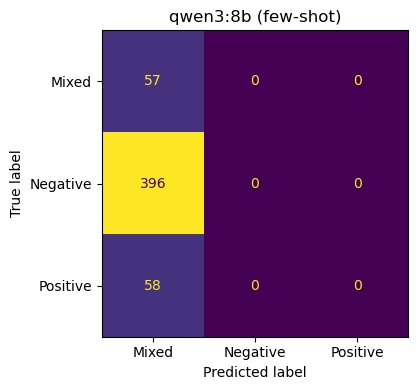

In [20]:
cm = confusion_matrix(y_test, llm_preds, labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique())).plot(ax=ax, colorbar=False)
ax.set_title(f"{MODEL} (few-shot)")
plt.tight_layout()
plt.show()

**Next:** line this macro-F1 up against the TF-IDF and `e5-large` embedding
notebooks — same 510-row test set, so the numbers are directly comparable. If you
also want the label-audit / pseudo-labeling use cases from the Tier 4 plan, that's a
separate run over the *full* `sentiment_df` (not just `X_test`) — worth keeping in a
different notebook so it doesn't get mixed up with this comparison.